<a href="https://colab.research.google.com/github/sa8692/Silver-Gold-Ratio-Trade/blob/main/Gold/Silver%20Pair%20Correlation%20With%20Interest%20Rates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Correlation between gsr and recessions/fed rates
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas_datareader.data import DataReader
from datetime import datetime

In [ ]:
start = "1970-01-01"
end   = datetime.today().strftime("%Y-%m-%d")

#client = RESTClient(api_key="BbPgmNVd7Y5XG0uZ9SYrZqWg1vng_eOH")

# Futures tickers
# gold  = yf.download("GC=F", start=start, end=end, progress=False, auto_adjust= False, interval = "1mo")["Adj Close"]
# silver= yf.download("SI=F", start=start, end=end, progress=False, auto_adjust= False, interval = "1mo")["Adj Close"]

# df = pd.concat([gold, silver], axis=1)
# df.columns = ["gold", "silver"]
# df = df.dropna()
# df["GSR"] = df["gold"] / df["silver"]

# recessions = DataReader("USREC", "fred", start, end)

# df = df.join(recessions).dropna()

# fedfunds = DataReader("FEDFUNDS", "fred", start, end)
# dgs10    = DataReader("DGS10", "fred", start, end) #10 yr treasury

# df = df.join(fedfunds).join(dgs10)
# df.rename(columns={"FEDFUNDS":"FedFunds", "DGS10":"Treasury10y"}, inplace=True)
# df = df.ffill() # carry forward rates
# print(df.head(n=15))

# df.to_csv("output.csv", sep=',', encoding='utf-8', index=False)


fedfunds = DataReader("FEDFUNDS", "fred", start, end)
dgs10    = DataReader("DGS10", "fred", start, end)
dgs10 = dgs10.resample("ME").mean()
dgs10 = dgs10.iloc[:-1]
usrec = DataReader("USREC", "fred", start, end)

index = fedfunds.index
df = pd.DataFrame({
    'FedFunds': fedfunds['FEDFUNDS'],
    'Treasury10y':dgs10['DGS10'].to_numpy(),
    'USREC':usrec['USREC']
}, index = index)

df = df.ffill() # carry forward rates

print(df)

gold = pd.read_csv("gold_historical.csv")
silver = pd.read_csv("silver_historical.csv")

index_drop = gold.index[gold['Date'] == '01/01/1970']
gold = gold.iloc[index_drop.astype(int)[0]:]
silver = silver.iloc[index_drop.astype(int)[0]:]
gold = gold.iloc[:-1]
silver = silver.iloc[:-1]

df['GSR'] = (gold['Value']/silver['Value']).to_numpy()
df["gold"] = gold["Value"].to_numpy()
df['silver'] = silver["Value"].to_numpy()

print(df.head(n=15))

            FedFunds  Treasury10y  USREC
DATE                                    
1970-01-01      8.98     7.794762      1
1970-02-01      8.98     7.238333      1
1970-03-01      7.76     7.072857      1
1970-04-01      8.10     7.390909      1
1970-05-01      7.95     7.906190      1
...              ...          ...    ...
2025-04-01      4.33     4.279048      0
2025-05-01      4.33     4.423810      0
2025-06-01      4.33     4.383500      0
2025-07-01      4.33     4.391818      0
2025-08-01      4.33     4.264762      0

[668 rows x 3 columns]
            FedFunds  Treasury10y  USREC        GSR   gold  silver
DATE                                                              
1970-01-01      8.98     7.794762      1  18.314136  34.98    1.91
1970-02-01      8.98     7.238333      1  18.421053  35.00    1.90
1970-03-01      7.76     7.072857      1  18.776596  35.30    1.88
1970-04-01      8.10     7.390909      1  20.843023  35.85    1.72
1970-05-01      7.95     7.906190      1 

                  GSR  FedFunds  Treasury10y
GSR          1.000000 -0.448201    -0.452402
FedFunds    -0.448201  1.000000     0.905990
Treasury10y -0.452402  0.905990     1.000000
(668, 6)


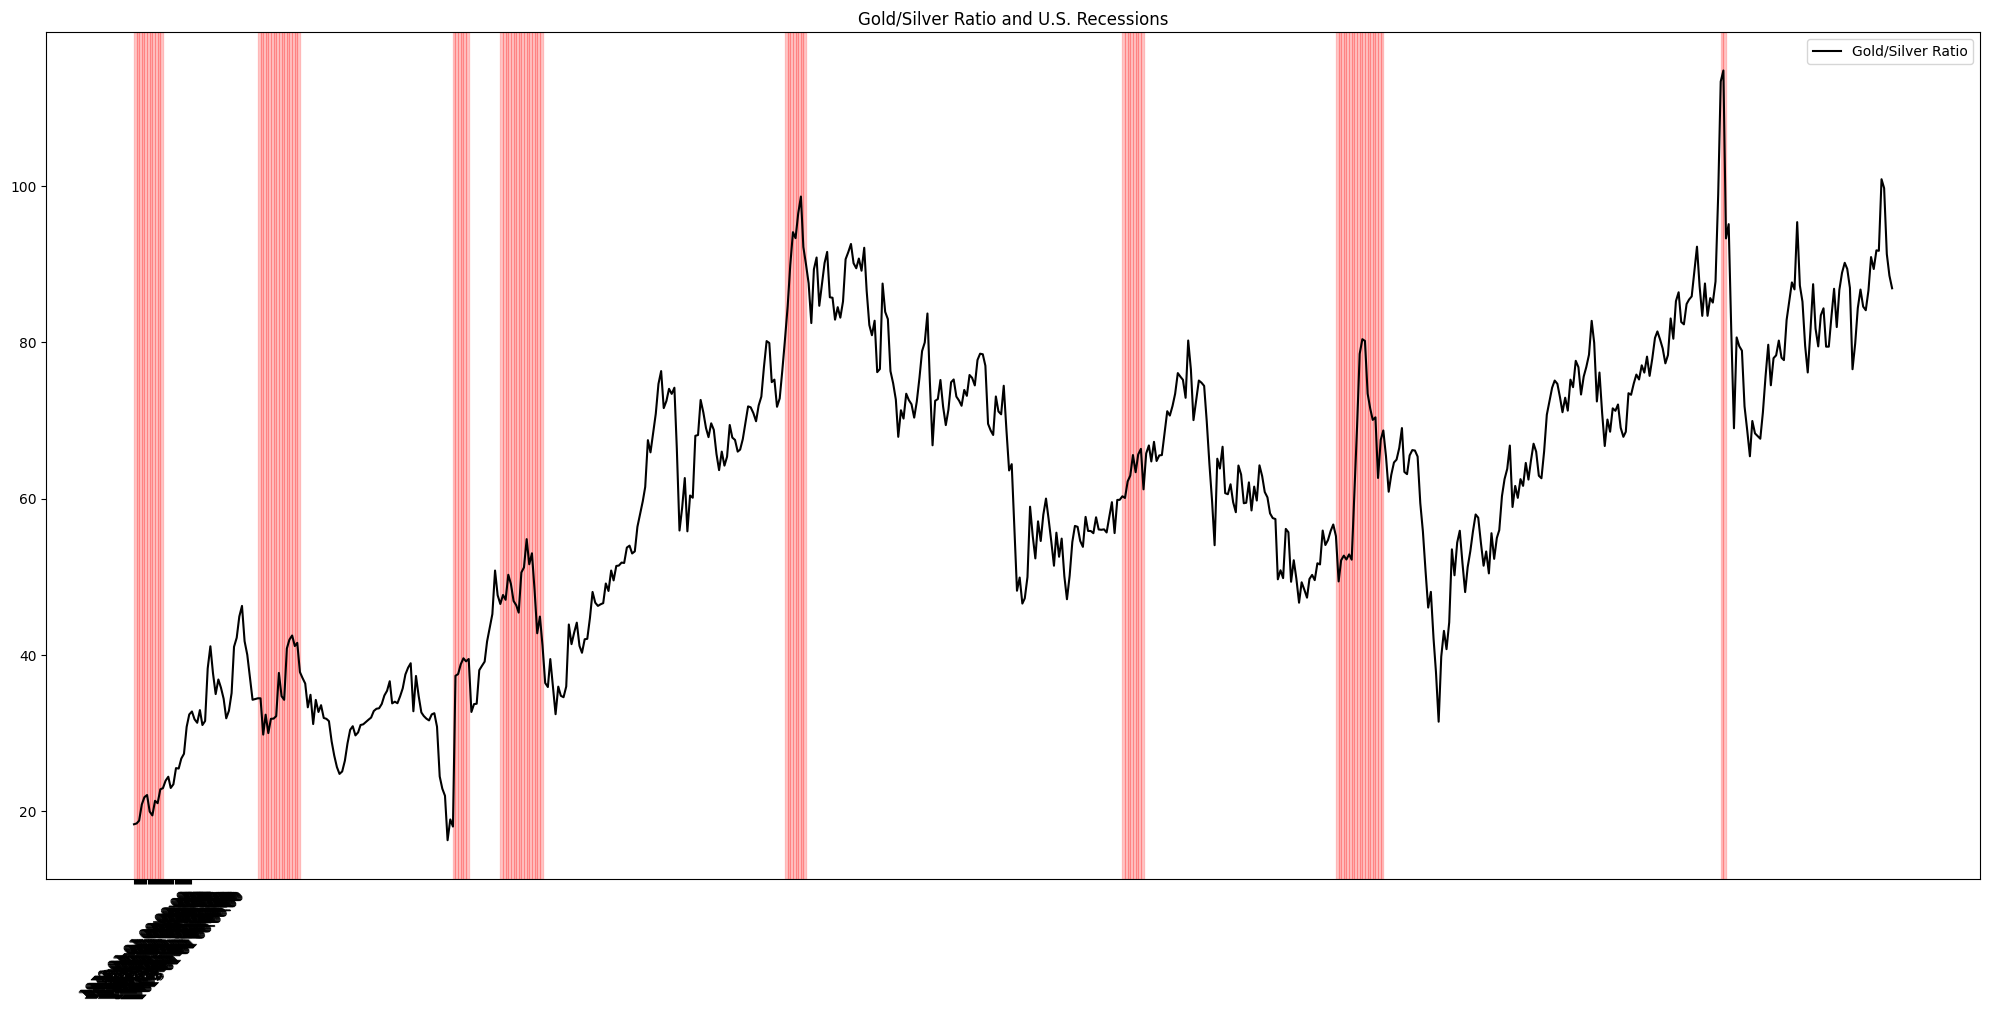

In [ ]:
print(df[["GSR","FedFunds","Treasury10y"]].corr())

print(df.shape)

plt.figure(figsize=(20,10))
plt.plot(df.index, df["GSR"], label="Gold/Silver Ratio", color="black")
plt.xticks(range(0, len(df.index), 12), df.index[::12], rotation = 45)

plt.tight_layout()
# shade recessions
for i in range(len(df)-1):
    if df["USREC"].iloc[i] == 1:
        plt.axvspan(df.index[i], df.index[i+1], color="red", alpha=0.2)

plt.title("Gold/Silver Ratio and U.S. Recessions")
plt.legend()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                    GSR   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     89.92
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           2.73e-35
Time:                        04:01:13   Log-Likelihood:                -2847.0
No. Observations:                 668   AIC:                             5700.
Df Residuals:                     665   BIC:                             5713.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          75.1385      1.623     46.288      

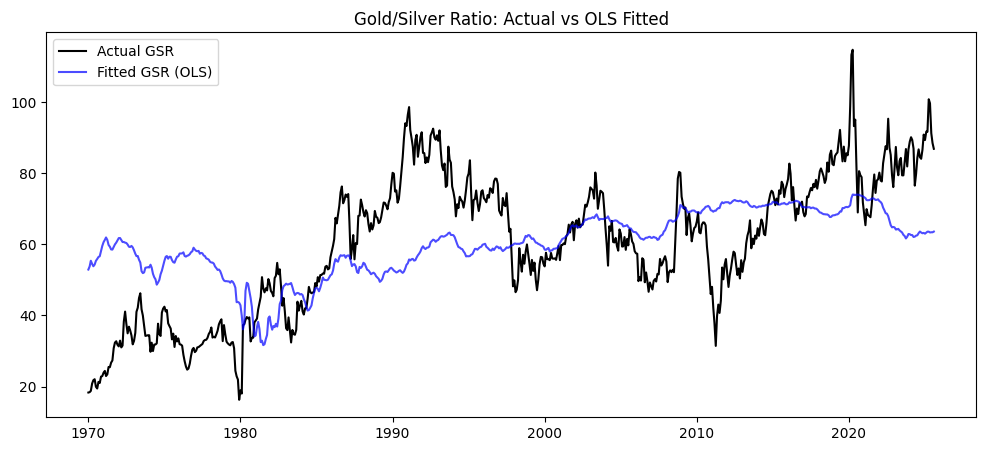

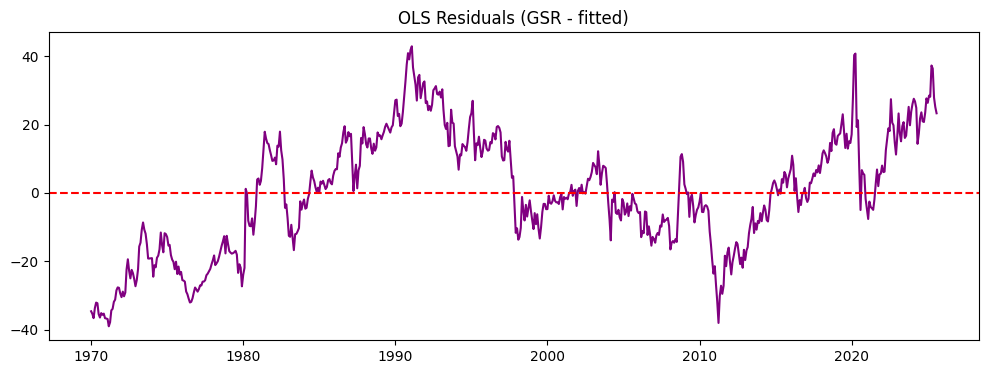

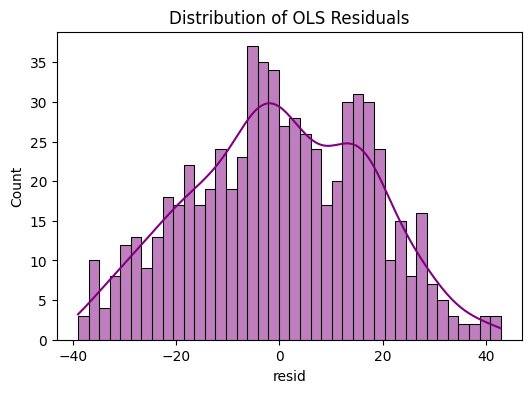

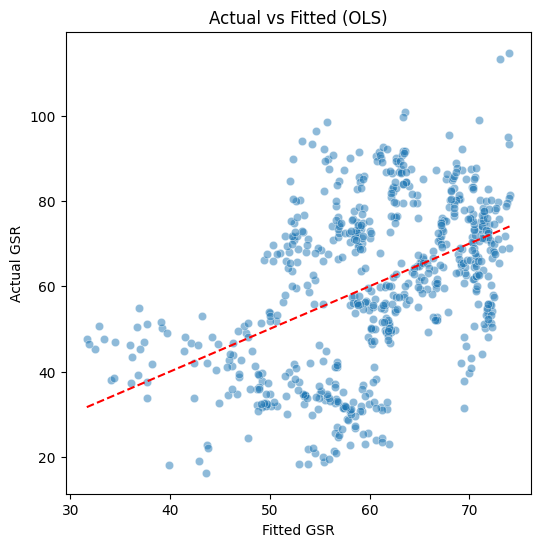

In [ ]:
import seaborn as sns

Y = df["GSR"]
X = sm.add_constant(df[["FedFunds","Treasury10y"]])
model = sm.OLS(Y, X, missing="drop").fit()
print(model.summary())

df["GSR_fit"] = model.fittedvalues
df["resid"]   = model.resid

# 1) Actual vs Fitted
plt.figure(figsize=(12,5))
plt.plot(df.index, df["GSR"], label="Actual GSR", color="black")
plt.plot(df.index, df["GSR_fit"], label="Fitted GSR (OLS)", color="blue", alpha=0.7)
plt.title("Gold/Silver Ratio: Actual vs OLS Fitted")
plt.legend()
plt.show()

# 2) Residuals over time
plt.figure(figsize=(12,4))
plt.plot(df.index, df["resid"], color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.title("OLS Residuals (GSR - fitted)")
plt.show()

# 3) Residuals histogram
plt.figure(figsize=(6,4))
sns.histplot(df["resid"].dropna(), bins=40, kde=True, color="purple")
plt.title("Distribution of OLS Residuals")
plt.show()

# 4) Actual vs Fitted scatter
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["GSR_fit"], y=df["GSR"], alpha=0.5)
plt.plot([df["GSR_fit"].min(), df["GSR_fit"].max()],
         [df["GSR_fit"].min(), df["GSR_fit"].max()],
         color="red", linestyle="--")
plt.xlabel("Fitted GSR")
plt.ylabel("Actual GSR")
plt.title("Actual vs Fitted (OLS)")
plt.show()


Relationship between 10yr T-bill and GSR due to low P-Value on previous test

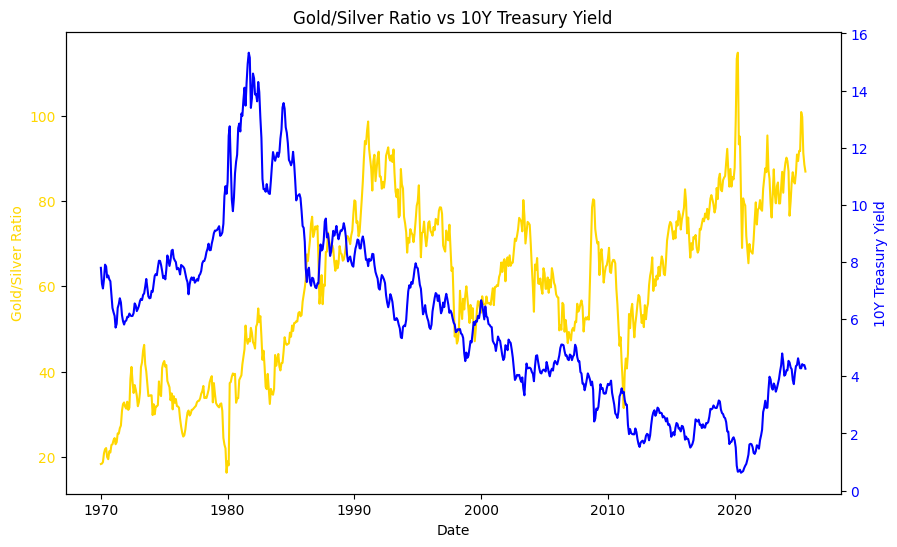

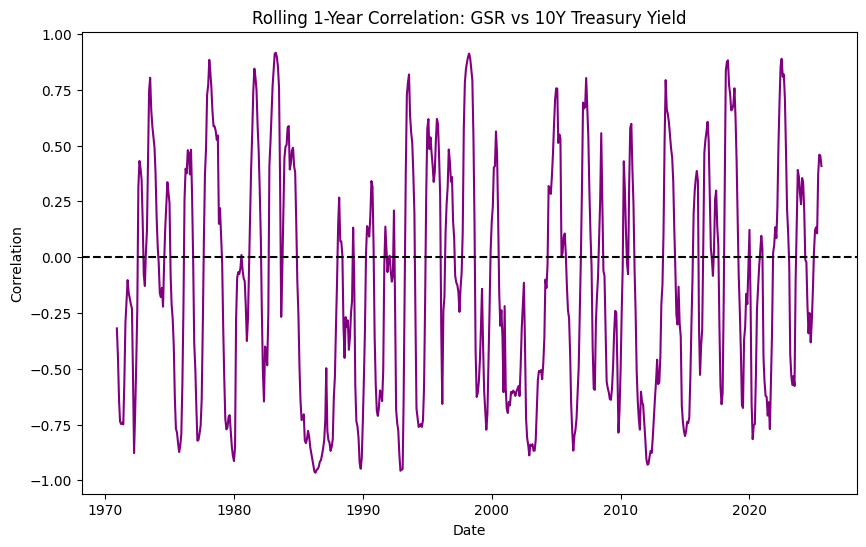

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.set_xlabel("Date")
ax1.set_ylabel("Gold/Silver Ratio", color="gold")
ax1.plot(df.index, df["GSR"], color="gold", label="GSR")
ax1.tick_params(axis="y", labelcolor="gold")

ax2 = ax1.twinx()
ax2.set_ylabel("10Y Treasury Yield", color="blue")
ax2.plot(df.index, df["Treasury10y"], color="blue", label="10Y Yield")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("Gold/Silver Ratio vs 10Y Treasury Yield")
plt.show()


rolling_corr = df["GSR"].rolling(12).corr(df["Treasury10y"])  # 12 trading months ≈ 1 year

plt.figure(figsize=(10,6))
plt.plot(rolling_corr, color="purple")
plt.axhline(0, linestyle="--", color="black")
plt.title("Rolling 1-Year Correlation: GSR vs 10Y Treasury Yield")
plt.ylabel("Correlation")
plt.xlabel("Date")
plt.show()

Coefficient: [[-0.02782508]] Intercept: [-0.37048235]
Optimization terminated successfully.
         Current function value: 0.363441
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 rec_t1   No. Observations:                  668
Model:                          Logit   Df Residuals:                      667
Method:                           MLE   Df Model:                            0
Date:                Tue, 30 Sep 2025   Pseudo R-squ.:                 0.03909
Time:                        04:01:14   Log-Likelihood:                -242.78
converged:                       True   LL-Null:                       -252.65
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
GSR           -0.0341      0.002    -15.787      0.000

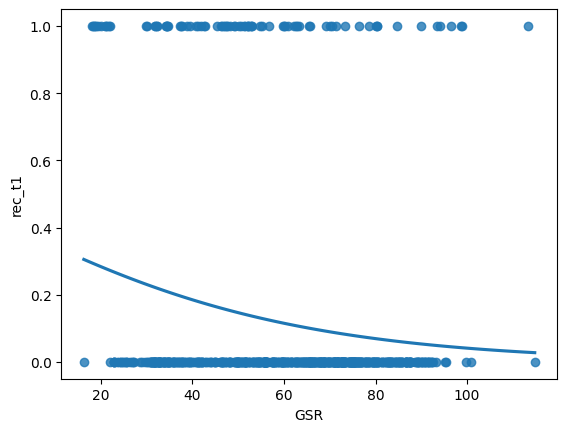

[[584   0]
 [ 84   0]]
Classification
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93       584
         1.0       0.00      0.00      0.00        84

    accuracy                           0.87       668
   macro avg       0.44      0.50      0.47       668
weighted avg       0.76      0.87      0.82       668

ROC-AUC: 0.6538649706457927


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


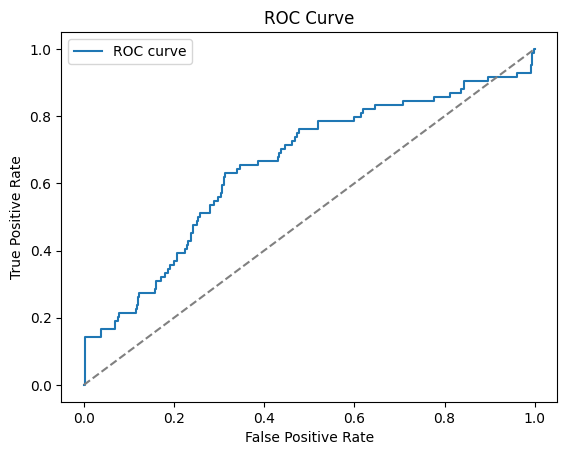

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

df["rec_t1"] = df["USREC"].shift(-1)  # recession next period
X = df[["GSR"]].dropna()
y = df["rec_t1"].dropna().reindex(X.index).ffill()

logit = LogisticRegression()
logit.fit(X, y)
print("Coefficient:", logit.coef_, "Intercept:", logit.intercept_)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

sns.regplot(x=X, y=y, data=df, logistic=True, ci=None)
plt.show()

#ROC curve
y_pred = logit.predict(X)
y_prob = logit.predict_proba(X)[:,1]

print(confusion_matrix(y, y_pred))
print('Classification')
print(classification_report(y, y_pred))
print("ROC-AUC:", roc_auc_score(y, y_prob))

fpr, tpr, thresholds = roc_curve(y, y_prob)
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**New Recession to GSR Approach**

Point-biserial correlation: -0.1677286422016049 p-value: 1.313442736561363e-05


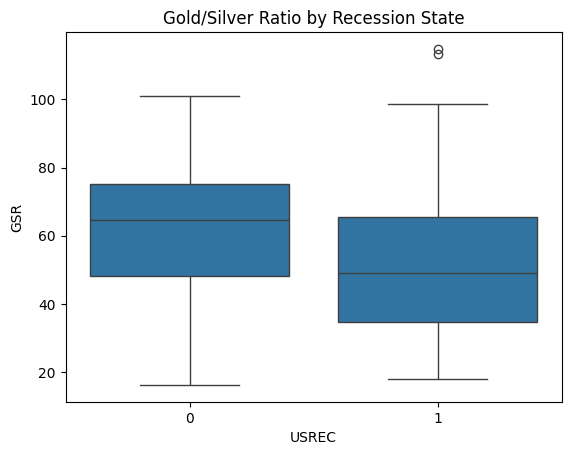

In [ ]:
from scipy.stats import pointbiserialr

corr, p_val = pointbiserialr(df["USREC"], df["GSR"])
print("Point-biserial correlation:", corr, "p-value:", p_val)

sns.boxplot(x="USREC", y="GSR", data=df)
plt.title("Gold/Silver Ratio by Recession State")
plt.show()

**Relate Recession to Fed Funds**

Point-biserial correlation: 0.2590053137497753 p-value: 1.0610151655334733e-11


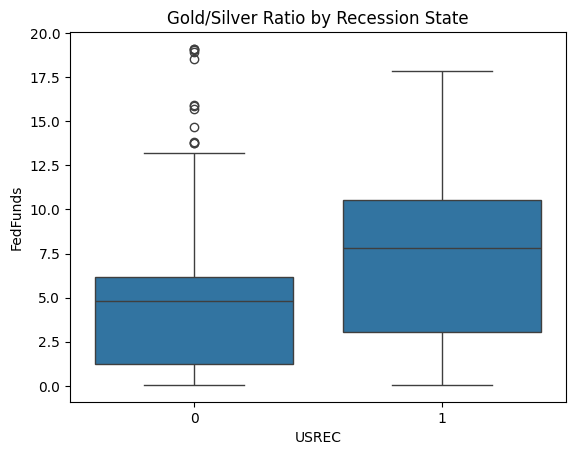

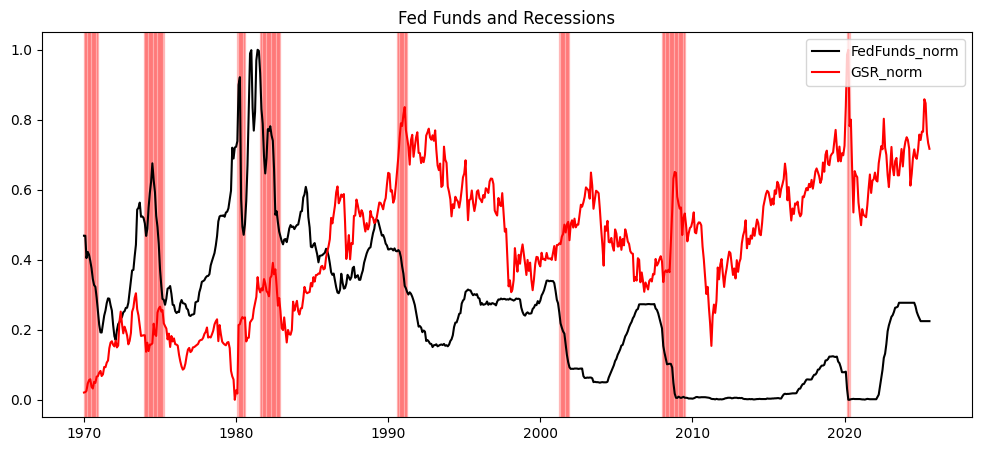

               GSR_norm  FedFunds_norm
GSR_norm       1.000000      -0.448201
FedFunds_norm -0.448201       1.000000


In [ ]:
corr, p_val = pointbiserialr(df["USREC"], df["FedFunds"])
print("Point-biserial correlation:", corr, "p-value:", p_val)

sns.boxplot(x="USREC", y="FedFunds", data=df)
plt.title("Gold/Silver Ratio by Recession State")
plt.show()




plt.figure(figsize=(12,5))
df["GSR_norm"] = (df["GSR"] - df["GSR"].min()) / (df["GSR"] .max() - df["GSR"] .min())
df["FedFunds_norm"] = (df["FedFunds"] - df["FedFunds"].min()) / (df["FedFunds"].max() - df["FedFunds"].min())
plt.plot(df.index, df["FedFunds_norm"], label="FedFunds_norm", color="black")
plt.plot(df.index, df["GSR_norm"] , label = "GSR_norm", color = "red")

# shade recessions
for i in range(len(df)-1):
    if df["USREC"].iloc[i] == 1:
        plt.axvspan(df.index[i], df.index[i+1], color="red", alpha=0.2)

plt.title("Fed Funds and Recessions")
plt.legend()
plt.show()


combined = pd.concat([df["GSR_norm"] , df["FedFunds_norm"]], axis=1)
print(combined.corr())


**GSR to CPI correlation: FRED and ShadowStats Data**

**CPI to Interest Rate correlation**

In [ ]:
cpi   = DataReader("CPIAUCSL", "fred", start, end)
cpi_pct = cpi.pct_change() * 100
df = df.join(cpi_pct)
df.rename(columns={"CPIAUCSL":"cpi_pct"}, inplace=True)
print(df)

            FedFunds  Treasury10y  USREC         GSR       gold   silver  \
DATE                                                                       
1970-01-01      8.98     7.794762      1   18.314136    34.9800   1.9100   
1970-02-01      8.98     7.238333      1   18.421053    35.0000   1.9000   
1970-03-01      7.76     7.072857      1   18.776596    35.3000   1.8800   
1970-04-01      8.10     7.390909      1   20.843023    35.8500   1.7200   
1970-05-01      7.95     7.906190      1   21.779141    35.5000   1.6300   
...              ...          ...    ...         ...        ...      ...   
2025-04-01      4.33     4.279048      0  100.853166  3288.7814  32.6096   
2025-05-01      4.33     4.423810      0   99.714904  3289.5548  32.9896   
2025-06-01      4.33     4.383500      0   91.286149  3266.4101  35.7821   
2025-07-01      4.33     4.391818      0   88.526290  3285.7772  37.1164   
2025-08-01      4.33     4.264762      0   86.901630  3373.9558  38.8250   

           

                            OLS Regression Results                            
Dep. Variable:                    GSR   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     107.9
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           2.71e-41
Time:                        04:01:15   Log-Likelihood:                -2826.8
No. Observations:                 667   AIC:                             5660.
Df Residuals:                     664   BIC:                             5673.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         73.0389      1.089     67.056      0.0

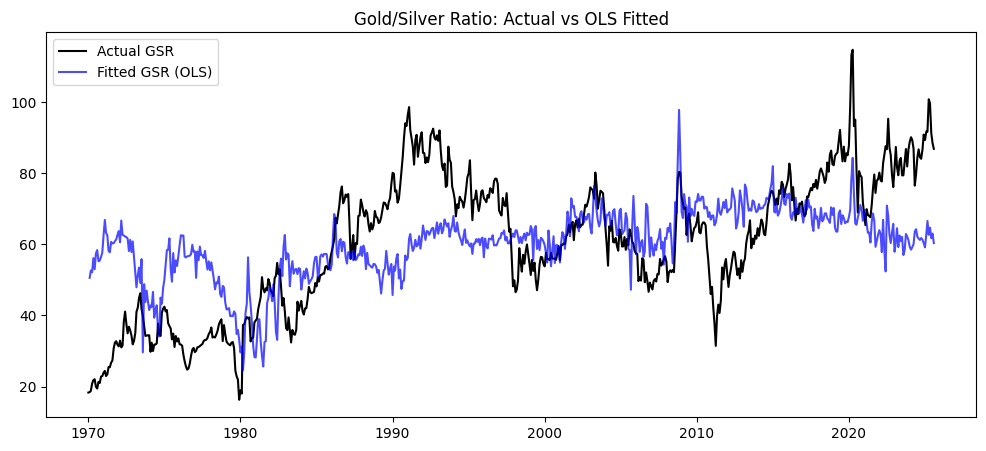

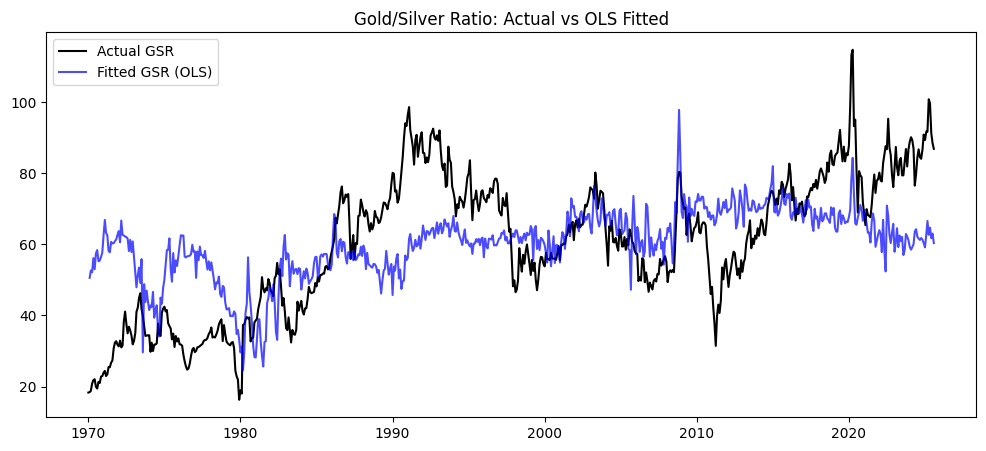

In [ ]:
Y = df["GSR"]
X = sm.add_constant(df[["cpi_pct","FedFunds"]])
model = sm.OLS(Y, X, missing="drop").fit()
print(model.summary())


df["GSR_fit_cpi_ff"] = model.fittedvalues

# 1) Actual vs Fitted
plt.figure(figsize=(12,5))
plt.plot(df.index, df["GSR"], label="Actual GSR", color="black")
plt.plot(df.index, df["GSR_fit_cpi_ff"], label="Fitted GSR (OLS)", color="blue", alpha=0.7)
plt.title("Gold/Silver Ratio: Actual vs OLS Fitted")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df.index, df["GSR"], label="Actual GSR", color="black")
plt.plot(df.index, df["GSR_fit_cpi_ff"], label="Fitted GSR (OLS)", color="blue", alpha=0.7)
plt.title("Gold/Silver Ratio: Actual vs OLS Fitted")
plt.legend()
plt.show()


In [ ]:
Y = df["GSR"]
X = sm.add_constant(df[["cpi_pct","FedFunds","Treasury10y","USREC"]])
model = sm.OLS(Y, X, missing="drop").fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    GSR   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     61.15
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           5.66e-44
Time:                        04:01:16   Log-Likelihood:                -2815.8
No. Observations:                 667   AIC:                             5642.
Df Residuals:                     662   BIC:                             5664.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          78.5970      1.631     48.193      

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

y = df["GSR"]
df["Treasury10y_filled"] = df["Treasury10y"].bfill()
df["cpi_filled"] = df["cpi_pct"].bfill()
X = sm.add_constant(df[["cpi_filled","USREC","Treasury10y_filled"]])

model = SARIMAX(y, order=(1,1,1), exog=X)
res = model.fit(disp=False)

print(res.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    GSR   No. Observations:                  668
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1780.812
Date:                Tue, 30 Sep 2025   AIC                           3575.623
Time:                        04:01:17   BIC                           3607.143
Sample:                    01-01-1970   HQIC                          3587.834
                         - 08-01-2025                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               8.071e-07   6.49e-09    124.397      0.000    7.94e-07     8.2e-07
cpi_filled            -1.1146      0.527     -2.114      0.034      -2.148      -0.081
USREC               

m1/real gpd expansion supply expansion

find range (low, mean, high) of gsr during recessionary periods

                            OLS Regression Results                            
Dep. Variable:                    GSR   R-squared:                       0.266
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     241.1
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           1.23e-46
Time:                        04:01:17   Log-Likelihood:                -2823.7
No. Observations:                 668   AIC:                             5651.
Df Residuals:                     666   BIC:                             5660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             74.2947      1.110     66.

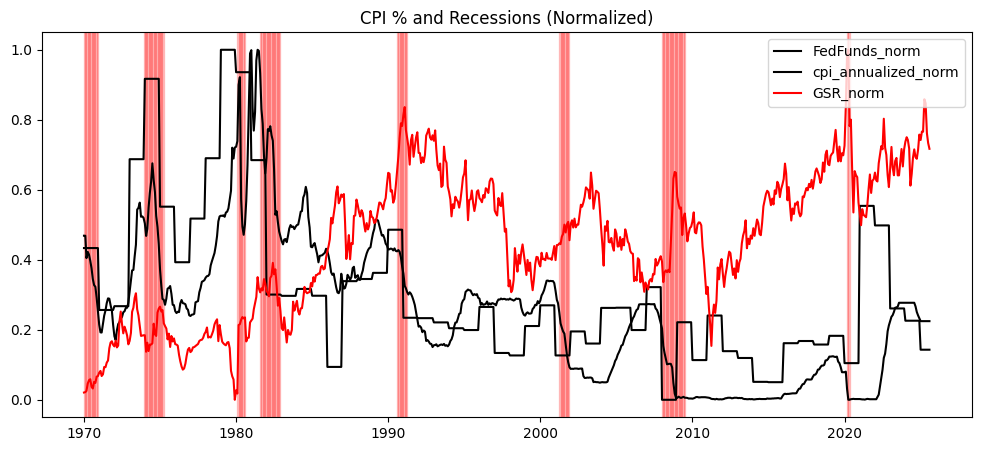

Norm Corr:  -0.5155739944378166


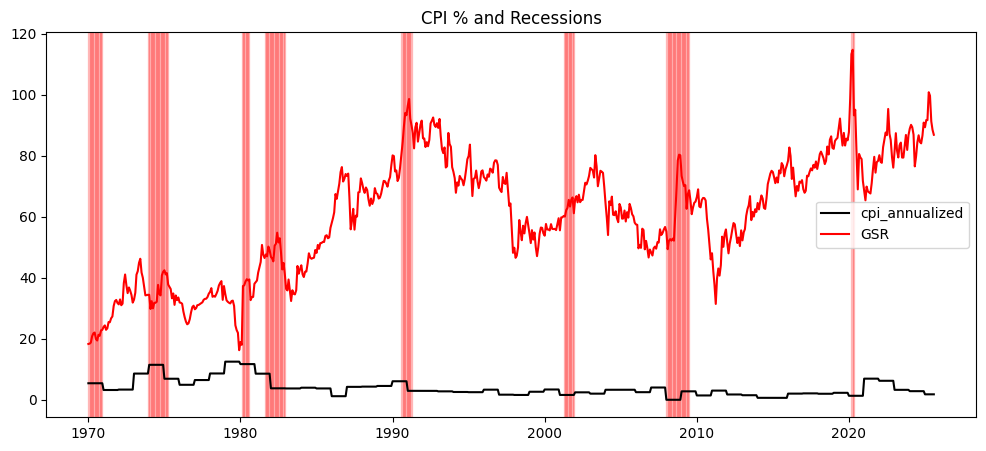

In [ ]:
y = df['GSR']

df['cpi_annualized'] = df.groupby(df.index.year)['cpi_filled'].transform('sum')

X=df['cpi_annualized']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

# Print results
print(model.summary())


plt.figure(figsize=(12,5))
df["GSR_norm"] = (df["GSR"] - df["GSR"].min()) / (df["GSR"] .max() - df["GSR"] .min())
df["cpi_annualized_norm"] = (df["cpi_annualized"] - df["cpi_annualized"].min()) / (df["cpi_annualized"].max() - df["cpi_annualized"].min())
plt.plot(df.index, df["FedFunds_norm"], label="FedFunds_norm", color="black")
plt.plot(df.index, df["cpi_annualized_norm"], label="cpi_annualized_norm", color="black")
plt.plot(df.index, df["GSR_norm"] , label = "GSR_norm", color = "red")

# shade recessions
for i in range(len(df)-1):
    if df["USREC"].iloc[i] == 1:
        plt.axvspan(df.index[i], df.index[i+1], color="red", alpha=0.2)

plt.title("CPI % and Recessions (Normalized)")
plt.legend()
plt.show()

corr = df["GSR_norm"].corr(df["cpi_annualized_norm"])
print("Norm Corr: ", corr)



plt.figure(figsize=(12,5))
plt.plot(df.index, df["cpi_annualized"], label="cpi_annualized", color="black")
plt.plot(df.index, df["GSR"] , label = "GSR", color = "red")
for i in range(len(df)-1):
    if df["USREC"].iloc[i] == 1:
        plt.axvspan(df.index[i], df.index[i+1], color="red", alpha=0.2)

plt.title("CPI % and Recessions")
plt.legend()
plt.show()

Linear R²: 0.20969068085946507
Linear RMSE: 335.65716653151827
RF R²: 0.10666274859310154
RF RMSE: 379.41479785457665


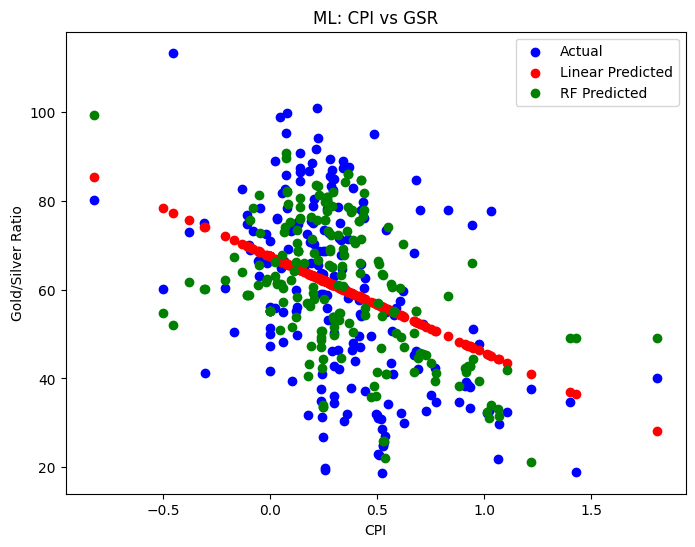

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X = df[["cpi_filled"]]
y = df["GSR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

print("Linear R²:", r2_score(y_test, y_pred_lr))
print("Linear RMSE:", mean_squared_error(y_test, y_pred_lr))


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RF R²:", r2_score(y_test, y_pred_rf))
print("RF RMSE:", mean_squared_error(y_test, y_pred_rf))

plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.scatter(X_test, y_pred_lr, color="red", label="Linear Predicted")
plt.scatter(X_test, y_pred_rf, color="green", label="RF Predicted")
plt.xlabel("CPI")
plt.ylabel("Gold/Silver Ratio")
plt.title("ML: CPI vs GSR")
plt.legend()
plt.show()


**Macro Lag**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

df_lag = pd.DataFrame({
    'GSR':df['GSR'],
    'cpi_filled':df['cpi_filled'],
    'FedFunds':df['FedFunds'],
    'Treasury10y':df['Treasury10y']
})



for col in ["cpi_filled", "FedFunds", "Treasury10y"]:
    for lag in range(1, 3):
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)

df_lag = df_lag.dropna()

print(df_lag)

train_size = int(len(df_lag)*0.7)
train, test = df_lag.iloc[:train_size], df_lag.iloc[train_size:]

X_train = train.drop(columns=["GSR"])
y_train = train["GSR"]

X_test = test.drop(columns=["GSR"])
y_test = test["GSR"]

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred)
    }

print(pd.DataFrame(results).T)


                   GSR  cpi_filled  FedFunds  Treasury10y  cpi_filled_lag1  \
DATE                                                                         
1970-03-01   18.776596    0.524934      7.76     7.072857         0.527704   
1970-04-01   20.843023    0.522193      8.10     7.390909         0.524934   
1970-05-01   21.779141    0.259740      7.95     7.906190         0.522193   
1970-06-01   22.055901    0.518135      7.61     7.841818         0.259740   
1970-07-01   19.937853    0.257732      7.21     7.457273         0.518135   
...                ...         ...       ...          ...              ...   
2025-04-01  100.853166    0.220891      4.33     4.279048        -0.050035   
2025-05-01   99.714904    0.080856      4.33     4.423810         0.220891   
2025-06-01   91.286149    0.286980      4.33     4.383500         0.080856   
2025-07-01   88.526290    0.196579      4.33     4.391818         0.286980   
2025-08-01   86.901630    0.382452      4.33     4.264762       

In [ ]:
df_normal = pd.DataFrame({
    'GSR':df['GSR'],
    'cpi_filled':df['cpi_filled'],
    'FedFunds':df['FedFunds'],
    'Treasury10y':df['Treasury10y']
})

train_size = int(len(df_normal)*0.7)
train, test = df_normal.iloc[:train_size], df_normal.iloc[train_size:]

X_train = train.drop(columns=["GSR"])
y_train = train["GSR"]

X_test = test.drop(columns=["GSR"])
y_test = test["GSR"]

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred)
    }

print(pd.DataFrame(results).T)

                        R2        RMSE
Linear           -0.946880  365.252879
RandomForest     -0.999702  375.162825
GradientBoosting -1.086164  391.383828


In [ ]:
max_lag = 60
results = {}

df_lag_reg = pd.DataFrame({
    'GSR':df['GSR'],
    'cpi_filled':df['cpi_filled'],
    'FedFunds':df['FedFunds'],
    'Treasury10y':df['Treasury10y'],
    'recession':df['USREC']
})

for lag in range(1, max_lag+1):
    df_lag_reg[f"recession_lag{lag}"] = df_lag_reg["recession"].shift(lag)

    subset = df_lag_reg.dropna()
    X = sm.add_constant(subset[f"recession_lag{lag}"])
    y = subset["GSR"]

    model = sm.OLS(y, X).fit()
    results[lag] = {"R2": model.rsquared_adj, "p": model.pvalues.iloc[1]}

best_lag = max(results, key=lambda k: results[k]["R2"])
print("Best lag (highest adj R²):", best_lag, results[best_lag])

X = sm.add_constant(subset[f"recession_lag{best_lag}"])
y = subset["GSR"]

model = sm.OLS(y,X).fit()
print(model.summary())



Best lag (highest adj R²): 33 {'R2': np.float64(0.08906851553605588), 'p': np.float64(9.470239292091706e-15)}
                            OLS Regression Results                            
Dep. Variable:                    GSR   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     54.57
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           4.99e-13
Time:                        04:01:21   Log-Likelihood:                -2584.7
No. Observations:                 608   AIC:                             5173.
Df Residuals:                     606   BIC:                             5182.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------

Take recession start date, find lag from start date
get info from sam's series

In [ ]:
print(df["GSR"].mean())


60.23524502191558


In [ ]:
max_lag = 60
results = {}

df_lag_reg = pd.DataFrame({
    'GSR':df['GSR'],
    'cpi_filled':df['cpi_filled'],
    'FedFunds':df['FedFunds'],
    'Treasury10y':df['Treasury10y'],
    'recession':df['USREC'],
    'gold':df['gold'],
    'silver':df['silver']
})

print(df_lag_reg)

for lag in range(1, max_lag+1):
    df_lag_reg[f"gold_lag{lag}"] = df_lag_reg["gold"].shift(lag)

    subset = df_lag_reg.dropna()
    X = sm.add_constant(subset[f"gold_lag{lag}"])
    y = subset["silver"]

    model = sm.OLS(y, X).fit()
    results[lag] = {"R2": model.rsquared_adj, "p": model.pvalues.iloc[1]}

best_lag = max(results, key=lambda k: results[k]["R2"])
print("Best lag (highest adj R²):", best_lag, results[best_lag])

X = sm.add_constant(subset[f"gold_lag{best_lag}"])
y = subset["GSR"]

model = sm.OLS(y,X).fit()
print(model.summary())


                   GSR  cpi_filled  FedFunds  Treasury10y  recession  \
DATE                                                                   
1970-01-01   18.314136    0.527704      8.98     7.794762          1   
1970-02-01   18.421053    0.527704      8.98     7.238333          1   
1970-03-01   18.776596    0.524934      7.76     7.072857          1   
1970-04-01   20.843023    0.522193      8.10     7.390909          1   
1970-05-01   21.779141    0.259740      7.95     7.906190          1   
...                ...         ...       ...          ...        ...   
2025-04-01  100.853166    0.220891      4.33     4.279048          0   
2025-05-01   99.714904    0.080856      4.33     4.423810          0   
2025-06-01   91.286149    0.286980      4.33     4.383500          0   
2025-07-01   88.526290    0.196579      4.33     4.391818          0   
2025-08-01   86.901630    0.382452      4.33     4.264762          0   

                 gold   silver  
DATE                          

calcualte